# Байесовский подход в анализе данных
## Задание 4

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * вставив ее в ноутбук посредством `Edit -> Insert Image` (<font color="red">фото, вставленные ссылкой, или отдельные файлы-картинки/pdf рядом с ноутбуком, не принимаются</font>);
  * в виде $\LaTeX$ в markdown-ячейках.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае вставки фото в ноутбук. <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 45 баллов;
* Задача 2 &mdash; 90 баллов;
* Задача 3 &mdash; 20 баллов;
* Задача 4 &mdash; 90 баллов.


---
### Задача 1.

Распишите итерационную процедуру EM-алгоритма и значение ELBO для метода Дэвида-Скина.

Напомним, функция неполного правдоподобия в данной модели имеет вид
$$p_{\pi,p}(N, Y) = \prod_{i\in I} \overbrace{\prod_{k \in K} \overbrace{\left( \overbrace{\rho_k}^{\stackrel{\text{\Large \textcolor{green}{вер-ть выбора}}}{\text{\textcolor{green}{этого класса}}}} \prod_{u\in U} \overbrace{\prod_{\ell \in K} \overbrace{\left( \pi_{k\ell}^u \right)^{n_{i\ell}^u} }^{\stackrel{\text{\large \textcolor{green}{$n_{i\ell}^u$ \Large раз поставлена}}}{\text{\textcolor{green}{метка $\ell$}}}}}^{\text{\textcolor{green}{фиксируем пользователя $u$}}} \right)^{\underbrace{Y_{ik}}_{\stackrel{\text{\large \textcolor{green}{выбор}}}{\text{\large \textcolor{green}{класса}}}}}}^{\text{\textcolor{green}{фиксируем для него истинный класс $k$}}}}^{\text{\textcolor{green}{рассматриваем объект $i$}}} \longrightarrow \max_{\pi, \rho}$$

где 
* $N = {n_{i\ell}^u}$ &mdash; наблюдаемые данные, $n_{i\ell}^u$ &mdash; количество раз, при которых разметчик $u \in U$ поставил класс $\ell \in K$ объекту $i \in I$;
* $Y_{ik} = I\{\text{объект } i \text{ класса } k\}$ &mdash; латентные величины;
* $\pi_{k\ell}^u$ &mdash; вероятность того, что разметчик $u$ поставил класс $\ell$ вместо правильного класса $k$, параметр модели;
* $\rho_k$ &mdash; вероятность класса $k$, параметр модели.

$\square$
## СМ. ПДФ
$\blacksquare$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import scipy.stats as sps
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import LabelEncoder

import numba
from numba import jit

---
### Задача 2.

**1.** Реализуйте следующие методы агрегации результатов разметки в краудсорсинге:
* голосование по большинству;
* метод Дэвида-Скина.

Результатом работы каждого метода должна быть таблица вероятностей классов для каждого объекта датасета. Итоговая метка получается выбором класса с наибольшей оценкой вероятности. 

*Замечания.*
* Метод голосования по большинству можно реализовать с помощью одной агрегирующей функцией `pandas.crosstab`.
* Метод Дэвида-Скина основывается на EM-алгоритме. При реализации должны быть учтены его особенности.
* При реализации используйте пример реализации GLAD, разобранный на занятии. В частности, используйте вспомогательные функции, ускорение с помощью `numba`.
* Постарайтесь написать красивый и понятный код, желательно &mdash; в виде классов.

In [2]:
@jit(nopython=True)
def log_sigmoid(x):
    if x >= 0:
        return -np.log1p(np.exp(-x))
    else:
        return x - np.log1p(np.exp(x))

@jit(nopython=True)
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

@jit(nopython=True)
def log_one_minus_sigmoid(x):
    if x >= 0:
        return -x - np.log1p(np.exp(-x))
    else:
        return -np.log1p(np.exp(x))

@jit(nopython=True)
def logsumexp(a):
    a_max = np.max(a)
    if not np.isfinite(a_max):
        return a_max
    s = np.sum(np.exp(a - a_max))
    return np.log(s) + a_max

In [3]:
class DavidSkin:
    def __init__(self, df, worker_col="worker_id", item_col="item_id", label_col="label",
                 df_majority_voting=None):
        worker_ids = df[worker_col].values
        item_ids = df[item_col].values
        labels = df[label_col].values
        self.num_classes = len(np.unique(labels))

        self.unique_workers = np.unique(worker_ids)
        self.unique_items = np.unique(item_ids)
        self.num_workers = len(self.unique_workers)
        self.num_items = len(self.unique_items)

        self.worker2ind = {w: i for i, w in enumerate(self.unique_workers)}
        self.item2ind = {t: i for i, t in enumerate(self.unique_items)}

        self.observations = np.empty((len(worker_ids), 3), dtype=np.int32)
        for idx, (w, t, l) in enumerate(zip(worker_ids, item_ids, labels)):
            self.observations[idx, 0] = self.worker2ind[w]
            self.observations[idx, 1] = self.item2ind[t]
            self.observations[idx, 2] = int(l)

        self.pi = 0.9 / self.num_classes + 0.1 * np.random.rand(self.num_workers, self.num_classes, self.num_classes)
        self.pi /= self.pi.sum(axis=2, keepdims=True)

        self.rhos = np.full(self.num_classes, 1.0 / self.num_classes)

        if df_majority_voting is not None:
            maj_dict = dict(zip(df_majority_voting["item_id"], df_majority_voting["predicted_label"]))
            self.gamma = np.zeros((self.num_items, self.num_classes))
            for item_id, internal_idx in self.item2ind.items():
                maj_label = maj_dict.get(item_id)
                if maj_label is not None:
                    if 0 <= maj_label < self.num_classes:
                        self.gamma[internal_idx, int(maj_label)] = 1.0
                    else:
                        self.gamma[internal_idx, :] = 1.0 / self.num_classes
                else:
                    self.gamma[internal_idx, :] = 1.0 / self.num_classes
            class_counts = np.zeros(self.num_classes)
            for item_id in self.unique_items:
                maj_label = maj_dict.get(item_id)
                if maj_label is not None and 0 <= maj_label < self.num_classes:
                    class_counts[int(maj_label)] += 1
            self.rhos = class_counts / class_counts.sum() if class_counts.sum() > 0 else np.full(self.num_classes, 1.0 / self.num_classes)
        else:
            self.gamma = np.random.dirichlet(alpha=np.ones(self.num_classes), size=self.num_items)

    @staticmethod
    @jit(nopython=True)
    def E_step_sparse(observations, log_pi, log_rhos, gamma, num_items, num_classes):
        log_likelihood = np.empty((num_items, num_classes), dtype=np.float64)
        for i in range(num_items):
            for k in range(num_classes):
                log_likelihood[i, k] = log_rhos[k]

        for obs_idx in range(observations.shape[0]):
            w, i, l = observations[obs_idx, 0], observations[obs_idx, 1], observations[obs_idx, 2]
            for k in range(num_classes):
                log_likelihood[i, k] += log_pi[w, k, l]

        for i in range(num_items):
            max_log = log_likelihood[i, 0]
            for k in range(1, num_classes):
                if log_likelihood[i, k] > max_log:
                    max_log = log_likelihood[i, k]
            exp_sum = 0.0
            for k in range(num_classes):
                val = np.exp(log_likelihood[i, k] - max_log)
                gamma[i, k] = val
                exp_sum += val
            for k in range(num_classes):
                gamma[i, k] /= exp_sum

    @staticmethod
    @jit(nopython=True)
    def M_step_sparse(observations, gamma, pi, rhos, num_classes, alpha, update_rhos=True):
        num_items = gamma.shape[0]
        num_workers = pi.shape[0]

        if update_rhos:
            for k in range(num_classes):
                total = 0.0
                for i in range(num_items):
                    total += gamma[i, k]
                rhos[k] = total / num_items

        counts = np.zeros((num_workers, num_classes, num_classes), dtype=np.float64)
        totals = np.zeros((num_workers, num_classes), dtype=np.float64)

        for obs_idx in range(observations.shape[0]):
            w, i, l = observations[obs_idx, 0], observations[obs_idx, 1], observations[obs_idx, 2]
            for k in range(num_classes):
                weight = gamma[i, k]
                counts[w, k, l] += weight
                totals[w, k] += weight

        for w in range(num_workers):
            for k in range(num_classes):
                denom = totals[w, k] + alpha * num_classes
                for l in range(num_classes):
                    pi[w, k, l] = (counts[w, k, l] + alpha) / denom

    @staticmethod
    @jit(nopython=True)
    def ELBO_sparse(observations, gamma, pi, rhos, num_items, num_classes):
        eps = 1e-12
        elbo = 0.0

        for i in range(num_items):
            for k in range(num_classes):
                g = gamma[i, k]
                if g > 0:
                    elbo += g * np.log(rhos[k] + eps)

        for obs_idx in range(observations.shape[0]):
            w, i, l = observations[obs_idx, 0], observations[obs_idx, 1], observations[obs_idx, 2]
            for k in range(num_classes):
                g = gamma[i, k]
                if g > 0:
                    elbo += g * np.log(pi[w, k, l] + eps)

        for i in range(num_items):
            for k in range(num_classes):
                g = gamma[i, k]
                if g > 0:
                    elbo -= g * np.log(g + eps)

        return elbo

    def fit(self, max_iter=100, tol=1e-4, alpha=1.0, verbose=True,
            M_step_first=False, dont_fit_class_probs=False):
        elbo_values = []
        eps = 1e-12

        if M_step_first:
            self.M_step_sparse(
                self.observations, self.gamma, self.pi, self.rhos,
                self.num_classes, alpha, update_rhos=not dont_fit_class_probs
            )

        log_pi = np.log(self.pi + eps)
        log_rhos = np.log(self.rhos + eps)

        iterator = tqdm(range(max_iter), desc="EM Iterations") if verbose else range(max_iter)

        for iteration in iterator:
            self.E_step_sparse(
                self.observations, log_pi, log_rhos, self.gamma,
                self.num_items, self.num_classes
            )

            elbo = self.ELBO_sparse(
                self.observations, self.gamma, self.pi, self.rhos,
                self.num_items, self.num_classes
            )
            elbo_values.append(elbo)

            if verbose:
                print(f"Iteration {iteration}, ELBO = {elbo:.6f}")

            if iteration > 0 and abs(elbo - elbo_values[-2]) < tol:
                if verbose:
                    print("Converged.")
                break

            self.M_step_sparse(
                self.observations, self.gamma, self.pi, self.rhos,
                self.num_classes, alpha, update_rhos=not dont_fit_class_probs
            )

            log_pi = np.log(self.pi + eps)
            log_rhos = np.log(self.rhos + eps)

        return elbo_values

    def predict(self):
        predicted_labels = np.argmax(self.gamma, axis=1)
        return pd.DataFrame({
            "item_id": self.unique_items,
            "predicted_label": predicted_labels
        })

In [4]:
class MajorityVoting:
    def __init__(self, df, worker_col="worker_id", item_col="item_id", label_col="label"):
        self.df = df.copy()
        self.num_classes = len(np.unique(df[label_col].values))
        self.worker_col = worker_col
        self.item_col = item_col
        self.label_col = label_col

    def predict(self):
        ct = pd.crosstab(
            index=self.df[self.item_col],
            columns=self.df[self.label_col],
            dropna=False
        )
        
        for cls in range(self.num_classes):
            if cls not in ct.columns:
                ct[cls] = 0
        
        ct = ct.reindex(sorted(ct.columns), axis=1)
        
        predicted_labels = ct.idxmax(axis=1)
        
        result = predicted_labels.reset_index()
        result.columns = [self.item_col, "predicted_label"]
        result["predicted_label"] = result["predicted_label"].astype(int)
        
        return result

In [5]:
class GLAD:
    def __init__(
        self,
        df,
        worker_col="worker_id",
        item_col="item_id",
        label_col="label",
        df_majority_voting=None,
    ):
        worker_ids = df[worker_col].values
        item_ids = df[item_col].values
        labels = df[label_col].values

        self.unique_workers = np.unique(worker_ids)
        self.unique_items = np.unique(item_ids)
        self.num_workers = len(self.unique_workers)
        self.num_items = len(self.unique_items)
        self.num_classes = len(np.unique(labels))

        self.worker2ind = {w: i for i, w in enumerate(self.unique_workers)}
        self.item2ind = {t: i for i, t in enumerate(self.unique_items)}

        self.users = np.array([self.worker2ind[w] for w in worker_ids], dtype=np.int32)
        self.objects = np.array([self.item2ind[t] for t in item_ids], dtype=np.int32)
        self.labels = np.array(labels, dtype=np.int32)

        self.log_pi, self.alpha, self.beta = self.initialize(df_majority_voting)

        if df_majority_voting is not None:
            maj_dict = dict(
                zip(
                    df_majority_voting["item_id"], df_majority_voting["predicted_label"]
                )
            )
            self.log_gamma = np.full((self.num_items, self.num_classes), -1e9)
            for item_id, internal_idx in self.item2ind.items():
                maj_label = maj_dict.get(item_id)
                if maj_label is not None and 0 <= maj_label < self.num_classes:
                    self.log_gamma[internal_idx, int(maj_label)] = 0.0
                else:
                    self.log_gamma[internal_idx, :] = -np.log(self.num_classes)
        else:
            self.log_gamma = np.zeros((self.num_items, self.num_classes))

    def initialize(self, df_majority_voting=None):
        alpha = np.ones(self.num_workers)
        beta = np.ones(self.num_items)

        if df_majority_voting is not None:
            maj_labels = df_majority_voting["predicted_label"].values
            valid_mask = (maj_labels >= 0) & (maj_labels < self.num_classes)
            valid_labels = maj_labels[valid_mask].astype(int)
            if len(valid_labels) > 0:
                counts = np.bincount(valid_labels, minlength=self.num_classes)
                pi = counts / counts.sum()
                pi = np.clip(pi, 1e-6, 1 - 1e-6)
                log_pi = np.log(pi)
            else:
                log_pi = np.log(np.full(self.num_classes, 1.0 / self.num_classes))
        else:
            log_pi = np.log(np.full(self.num_classes, 1.0 / self.num_classes))

        return log_pi, alpha, beta

    @staticmethod
    @jit(nopython=True)
    def E_step(users, objects, labels, alpha, beta, log_pi, objects_count, class_count):
        M = len(labels)
        log_gamma = np.zeros((objects_count, class_count)) + log_pi.reshape((1, -1))
        for m in range(M):
            u = users[m]
            i = objects[m]
            x = labels[m]
            neg_prob = log_one_minus_sigmoid(alpha[u] * beta[i]) - np.log(
                class_count - 1
            )
            for k in range(class_count):
                if x == k:
                    log_gamma[i, k] += log_sigmoid(alpha[u] * beta[i])
                else:
                    log_gamma[i, k] += neg_prob
        for i in range(objects_count):
            log_gamma[i] -= logsumexp(log_gamma[i])
        return log_gamma

    @staticmethod
    @jit(nopython=True)
    def M_step(
        users,
        objects,
        labels,
        alpha,
        beta,
        log_gamma,
        objects_count,
        class_count,
        lr=0.0001,
        n_iter=50,
    ):
        M = len(labels)
        log_pi = np.zeros(class_count)
        for k in range(class_count):
            log_pi[k] = logsumexp(log_gamma[:, k]) - np.log(objects_count)
        gamma = np.exp(log_gamma)
        for _ in range(n_iter):
            alpha_iter = alpha[:]
            beta_iter = beta[:]
            for m in range(M):
                u = users[m]
                i = objects[m]
                x = labels[m]
                sigma = sigmoid(alpha[u] * beta[i])
                for k in range(class_count):
                    alpha_iter[u] += lr * gamma[i, k] * beta[i] * (int(x == k) - sigma)
                    beta_iter[i] += lr * gamma[i, k] * alpha[u] * (int(x == k) - sigma)
            alpha = alpha_iter
            beta = beta_iter
        return alpha, beta, log_pi

    @staticmethod
    @jit(nopython=True)
    def elbo(
        users,
        objects,
        labels,
        alpha,
        beta,
        log_pi,
        log_gamma,
        objects_count,
        class_count,
    ):
        M = len(labels)
        gamma = np.exp(log_gamma)
        elbo_value = (gamma * log_pi.reshape((1, -1))).sum() - (gamma * log_gamma).sum()
        for m in range(M):
            u = users[m]
            i = objects[m]
            x = labels[m]
            neg_prob = log_one_minus_sigmoid(alpha[u] * beta[i]) - np.log(
                class_count - 1
            )
            for k in range(class_count):
                if x == k:
                    elbo_value += gamma[i, k] * log_sigmoid(alpha[u] * beta[i])
                else:
                    elbo_value += gamma[i, k] * neg_prob
        return elbo_value

    def fit(self, n_iter=50, n_init=5, lr=0.0001, verbose=False):
        best_elbo = -np.inf
        best_params = {}
        for init in tqdm(range(n_init), desc=f"GLAD n_init={n_init}"):
            self.log_pi, self.alpha, self.beta = self.initialize()
            for it in tqdm(range(n_iter), desc="EM Iterations"):
                self.log_gamma = self.E_step(
                    self.users,
                    self.objects,
                    self.labels,
                    self.alpha,
                    self.beta,
                    self.log_pi,
                    self.num_items,
                    self.num_classes,
                )
                self.alpha, self.beta, self.log_pi = self.M_step(
                    self.users,
                    self.objects,
                    self.labels,
                    self.alpha,
                    self.beta,
                    self.log_gamma,
                    self.num_items,
                    self.num_classes,
                    lr=lr,
                )
                current_elbo = self.elbo(
                    self.users,
                    self.objects,
                    self.labels,
                    self.alpha,
                    self.beta,
                    self.log_pi,
                    self.log_gamma,
                    self.num_items,
                    self.num_classes,
                )
                if verbose:
                    print(f"Current ELBO: {current_elbo}")
            if current_elbo > best_elbo:
                best_elbo = current_elbo
                best_params = {
                    "gamma": np.exp(self.log_gamma),
                    "pi": np.exp(self.log_pi),
                    "alpha": self.alpha.copy(),
                    "beta": self.beta.copy(),
                    "elbo": best_elbo,
                }
        self.gamma = best_params["gamma"]
        self.pi = best_params["pi"]
        self.alpha = best_params["alpha"]
        self.beta = best_params["beta"]
        self.best_elbo = best_params["elbo"]
        return best_params

    def predict(self):
        predicted_labels = np.argmax(self.gamma, axis=1)
        return pd.DataFrame(
            {"item_id": self.unique_items, "predicted_label": predicted_labels}
        )

**2.** Примените эти два метода и метод GLAD с занятия к следующим <a href="https://toloka.ai/ru/datasets">открытым данным</a> Яндекс.Толоки:
* Toloka Aggregation Features;
* Toloka Aggregation Relevance 2;
* Toloka Aggregation Relevance 5.

Обратите внимание, что в последнем датасете 5 различных меток, причем некоторые объекты в датасете имеют не один, а несколько правильных ответов. Любой из таких ответов считается правильным.

Реализацию метода GLAD возьмите с занятия.

## Toloka Aggregation Relevance 2

In [6]:
toloka_relevance_2_crowd = pd.read_csv("toloka_relevance_2/crowd_labels.tsv", sep="\t", header=None, names=["worker_id", "item_id", "label"])
toloka_relevance_2_true = pd.read_csv("toloka_relevance_2/golden_labels.tsv", sep="\t", header=None, names=["item_id", "true_label"])

toloka_relevance_2_crowd["item_id"] = toloka_relevance_2_crowd["item_id"].astype(str)
toloka_relevance_2_true["item_id"] = toloka_relevance_2_true["item_id"].astype(str)

In [7]:
DavidSkin_model = DavidSkin(toloka_relevance_2_crowd)
GLAD_model = GLAD(toloka_relevance_2_crowd)
MajorityVoting_model = MajorityVoting(toloka_relevance_2_crowd)

In [8]:
DavidSkin_model.fit(max_iter=200, tol=1e-4);

EM Iterations:   0%|          | 0/200 [00:00<?, ?it/s]

Iteration 0, ELBO = -329721.112348
Iteration 1, ELBO = -297201.554927
Iteration 2, ELBO = -297154.067364
Iteration 3, ELBO = -297058.185921
Iteration 4, ELBO = -296814.540739
Iteration 5, ELBO = -296131.988302
Iteration 6, ELBO = -294200.254935
Iteration 7, ELBO = -289495.997366
Iteration 8, ELBO = -281554.977285
Iteration 9, ELBO = -273509.806298
Iteration 10, ELBO = -268228.542820
Iteration 11, ELBO = -265494.244083
Iteration 12, ELBO = -264265.957810
Iteration 13, ELBO = -263745.539115
Iteration 14, ELBO = -263527.647284
Iteration 15, ELBO = -263440.045337
Iteration 16, ELBO = -263403.773834
Iteration 17, ELBO = -263387.452765
Iteration 18, ELBO = -263379.519194
Iteration 19, ELBO = -263375.437136
Iteration 20, ELBO = -263373.253318
Iteration 21, ELBO = -263372.057919
Iteration 22, ELBO = -263371.400320
Iteration 23, ELBO = -263371.047175
Iteration 24, ELBO = -263370.873409
Iteration 25, ELBO = -263370.809131
Iteration 26, ELBO = -263370.812778
Iteration 27, ELBO = -263370.857805
It

In [9]:
GLAD_model.fit(n_init=10, lr=0.0001);

GLAD n_init=10:   0%|          | 0/10 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

...

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

In [10]:
predicted_DavidSkin = DavidSkin_model.predict()
predicted_GLAD = GLAD_model.predict()
predicted_MajorityVoting = MajorityVoting_model.predict()

In [11]:
def compute_accuracy_relevance_2(true_df: pd.DataFrame, pred_df: pd.DataFrame) -> float:
    merged = pd.merge(true_df, pred_df, on="item_id", how="inner")
    
    correct = (merged["true_label"] == merged["predicted_label"]).sum()
    total = len(merged)
    
    accuracy = correct / total if total > 0 else float('nan')
    return max(accuracy, 1 - accuracy)

In [12]:
DavidSkin_acc = compute_accuracy_relevance_2(toloka_relevance_2_true, predicted_DavidSkin)
GLAD_acc = compute_accuracy_relevance_2(toloka_relevance_2_true, predicted_GLAD)
MajorityVoting_acc = compute_accuracy_relevance_2(toloka_relevance_2_true, predicted_MajorityVoting)

print(f"DavidSkin Accuracy: {DavidSkin_acc:.4f}")
print(f"GLAD Accuracy: {GLAD_acc:.4f}")
print(f"Majority Voting Accuracy: {MajorityVoting_acc:.4f}")

DavidSkin Accuracy: 0.8103
GLAD Accuracy: 0.7559
Majority Voting Accuracy: 0.7764


## Toloka Relevance 5

In [17]:
toloka_relevance_5_crowd = pd.read_csv(
    "toloka_relevance_5/crowd_labels.tsv",
    sep="\t",
    header=None,
    names=["worker_id", "item_id", "label"],
)
toloka_relevance_5_true = pd.read_csv(
    "toloka_relevance_5/golden_labels.tsv",
    sep="\t",
    header=None,
    names=["item_id", "true_label"],
)

toloka_relevance_5_crowd["item_id"] = toloka_relevance_5_crowd["item_id"].astype(str)
toloka_relevance_5_true["item_id"] = toloka_relevance_5_true["item_id"].astype(str)

In [18]:
DavidSkin_model = DavidSkin(toloka_relevance_5_crowd)
GLAD_model = GLAD(toloka_relevance_5_crowd)
MajorityVoting_model = MajorityVoting(toloka_relevance_5_crowd)

In [19]:
DavidSkin_model.fit(max_iter=2000, tol=1e-4, alpha=1, verbose=False);

In [20]:
GLAD_model.fit(n_init=3, lr=0.0001);

GLAD n_init=3:   0%|          | 0/3 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

In [21]:
predicted_DavidSkin = DavidSkin_model.predict()
predicted_GLAD = GLAD_model.predict()
predicted_MajorityVoting = MajorityVoting_model.predict()

In [22]:
def compute_accuracy_relevance_5(true_df: pd.DataFrame, pred_df: pd.DataFrame) -> float:
    merged = pred_df.merge(true_df, on="item_id", how="inner")
    
    if merged.empty:
        return 0.0

    y_true = merged["true_label"].values
    y_pred = merged["predicted_label"].values

    le_true = LabelEncoder()
    le_pred = LabelEncoder()
    
    y_true_enc = le_true.fit_transform(y_true)
    y_pred_enc = le_pred.fit_transform(y_pred)
    
    num_true_classes = len(le_true.classes_)
    num_pred_classes = len(le_pred.classes_)
    num_classes = max(num_true_classes, num_pred_classes)

    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true_enc, y_pred_enc):
        cm[t, p] += 1

    row_ind, col_ind = linear_sum_assignment(-cm)

    pred_to_true_map = {col: row for row, col in zip(row_ind, col_ind)}

    y_pred_remapped = np.array([pred_to_true_map.get(p, p) for p in y_pred_enc])

    merged["correct"] = (y_pred_remapped == y_true_enc)
    grouped = merged.groupby("item_id")["correct"].any()
    return float(grouped.mean())

In [23]:
DavidSkin_acc = compute_accuracy_relevance_5(toloka_relevance_5_true, predicted_DavidSkin)
GLAD_acc = compute_accuracy_relevance_5(toloka_relevance_5_true, predicted_GLAD)
MajorityVoting_acc = compute_accuracy_relevance_5(toloka_relevance_5_true, predicted_MajorityVoting)

print(f"DavidSkin Accuracy: {DavidSkin_acc:.4f}")
print(f"GLAD Accuracy: {GLAD_acc:.4f}")
print(f"Majority Voting Accuracy: {MajorityVoting_acc:.4f}")

DavidSkin Accuracy: 0.8683
GLAD Accuracy: 0.6455
Majority Voting Accuracy: 0.9014


## TOLOKA AGGREGATION FEATURES


In [24]:
toloka_aggregation_crowd = pd.read_csv("toloka_features_aggregation/crowd_labels.tsv", sep="\t", header=None, names=["worker_id", "item_id", "label"])
toloka_aggregation_true = pd.read_csv("toloka_features_aggregation/golden_labels.tsv", sep="\t", header=None, names=["item_id", "true_label"])

toloka_aggregation_crowd["item_id"] = toloka_aggregation_crowd["item_id"].astype(str)
toloka_aggregation_true["item_id"] = toloka_aggregation_true["item_id"].astype(str)

In [25]:
DavidSkin_model = DavidSkin(toloka_aggregation_crowd)
GLAD_model = GLAD(toloka_aggregation_crowd)
MajorityVoting_model = MajorityVoting(toloka_aggregation_crowd)

In [26]:
DavidSkin_model.fit();

EM Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

Iteration 0, ELBO = -97668.794352
Iteration 1, ELBO = -58467.081022
Iteration 2, ELBO = -34415.081714
Iteration 3, ELBO = -32487.226176
Iteration 4, ELBO = -31765.689592
Iteration 5, ELBO = -31415.561287
Iteration 6, ELBO = -31287.961003
Iteration 7, ELBO = -31262.369376
Iteration 8, ELBO = -31233.346245
Iteration 9, ELBO = -31211.093142
Iteration 10, ELBO = -30802.155892
Iteration 11, ELBO = -30573.220652
Iteration 12, ELBO = -30563.635991
Iteration 13, ELBO = -30560.238870
Iteration 14, ELBO = -30567.177394
Iteration 15, ELBO = -30567.181874
Iteration 16, ELBO = -30567.179088
Iteration 17, ELBO = -30567.181144
Iteration 18, ELBO = -30567.184788
Iteration 19, ELBO = -30567.188527
Iteration 20, ELBO = -30567.191840
Iteration 21, ELBO = -30567.194596
Iteration 22, ELBO = -30567.196814
Iteration 23, ELBO = -30567.198559
Iteration 24, ELBO = -30567.199912
Iteration 25, ELBO = -30567.200949
Iteration 26, ELBO = -30567.201737
Iteration 27, ELBO = -30567.202330
Iteration 28, ELBO = -30567.20

In [27]:
GLAD_model.fit(n_init=10, lr=0.0001);

GLAD n_init=10:   0%|          | 0/10 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

...

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

In [28]:
predicted_DavidSkin = DavidSkin_model.predict()
predicted_GLAD = GLAD_model.predict()
predicted_MajorityVoting = MajorityVoting_model.predict()

In [29]:
DavidSkin_acc = compute_accuracy_relevance_5(toloka_aggregation_true, predicted_DavidSkin)
GLAD_acc = compute_accuracy_relevance_5(toloka_aggregation_true, predicted_GLAD)
MajorityVoting_acc = compute_accuracy_relevance_5(toloka_aggregation_true, predicted_MajorityVoting)

print(f"DavidSkin Accuracy: {DavidSkin_acc:.4f}")
print(f"GLAD Accuracy: {GLAD_acc:.4f}")
print(f"Majority Voting Accuracy: {MajorityVoting_acc:.4f}")

DavidSkin Accuracy: 0.3905
GLAD Accuracy: 0.6014
Majority Voting Accuracy: 0.8396


Как видим, мы свалились в субоптимум в DavidSkin. Скорее всего это связано с неудачной инициализацией gamma. Ниже мы попробуем это исправить, инициализировав ее через majority voting. Похожее случилось и с GLAD.

**3.** Насколько хорошее получается качество в методах, основанных на EM?

Попробуйте следующие модификации методов, основанных на EM.
* В качестве начального приближения вероятностей классов для каждого объекта подавать те вероятности, которые посчитаны методом голосования по большинству, и провести сначала M-шаг. Можно также сделать случайный выбор значений в соответствующей окрестности или же делать "жёсткую" привязку. 
* В качестве вероятностей классов в целом по датасету "жёстко" фиксировать те вероятности, которые были получены в методе голосования по большинству, и не подбирать их в процессе EM-алгоритма.
* В методе GLAD в качестве начального приближения подавать такие значения $\alpha$ и $\beta$, которые не делают различий между разными пользователями и между разными объектами.

3.1

In [30]:
DavidSkin_model = DavidSkin(
    toloka_aggregation_crowd, df_majority_voting=predicted_MajorityVoting
)
DavidSkin_model.fit(M_step_first=True, max_iter=1000, alpha=10, tol=1e-8, verbose=False);
predicted_DavidSkin = DavidSkin_model.predict()
DavidSkin_acc = compute_accuracy_relevance_5(
    toloka_aggregation_true, predicted_DavidSkin
)

print(f"DavidSkin Accuracy: {DavidSkin_acc:.4f}")

DavidSkin Accuracy: 0.8325


3.2

In [31]:
DavidSkin_model = DavidSkin(
    toloka_aggregation_crowd, df_majority_voting=predicted_MajorityVoting
)
DavidSkin_model.fit(
    M_step_first=True, dont_fit_class_probs=True, max_iter=1000, tol=1e-8, alpha=7, verbose=False
)
predicted_DavidSkin = DavidSkin_model.predict()
DavidSkin_acc = compute_accuracy_relevance_5(
    toloka_aggregation_true, predicted_DavidSkin
)

print(f"DavidSkin Accuracy: {DavidSkin_acc:.4f}")

DavidSkin Accuracy: 0.8285


3.3

In [32]:
GLAD_model = GLAD(
    toloka_aggregation_crowd, df_majority_voting=predicted_MajorityVoting
)
GLAD_model.fit(
    n_init=5, lr=1e-5, verbose=False, n_iter=150
)
predicted_GLAD = GLAD_model.predict()
GLAD_acc = compute_accuracy_relevance_5(
    toloka_aggregation_true, predicted_GLAD
)

print(f"GLAD Accuracy: {GLAD_acc:.4f}")

GLAD n_init=5:   0%|          | 0/5 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/150 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/150 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/150 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/150 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/150 [00:00<?, ?it/s]

GLAD Accuracy: 0.6206


**Выводы**

Мы написали два алгоритма являющихся альтернативой majority voting.

Мы видим основные недостатки: GLAD и DavidSkin плохо отрабатывают на малых датасетах в виду недостатка данных. Также для результата работы этих алгоритмов необходимо проводить выравнивание меток, чтобы они согласовались с истинными. Надо отметить, что GLAD нигде не показал лучшего качества, но при этом его обучение занимает очень много времени, так как его приходится запускать несколько раз.

Но основной проблемой обоих методов является необходимость подбора гиперпараметров, так как без него они могут работать кратно хуже.

Мы видим и плюсы, в бинарной классификации DavidSkin показал качество намного лучше чем у majority voting. Также, если передать ему в виде начального приближения данные полученные при помощи majority voting его качество кратно растет (хоть в силу небольшого размера датасета и не перебивает Majority voting).

__________________
### Задача 3.

Реализуйте генерацию дискретного распределения из процесса Дирихле, используя процесс stick-breaking.

In [33]:
def dirichlet_processes(base_distibution :sps.rv_discrete, alpha, tolerance=1e-8):
    """
    Генерация дискретного распределения на основе процесса stick-breaking.
    base_distibution --- базовое распределение
    alpha --- параметр разреженности
    tolerance --- точность

    Возвращает:
    values --- носитель (значения) получаемой вероятностной меры
    probs --- соответствующие вероятности
    """

    values = []
    probs = []

    # Если сумма уже сгенерированных вероятностей не меньше 1-tolerance,
    # то процесс завершается.

    pi_arr = []
    pi_sum = 0
    x_arr = []
    v_arr = []
    beta_distr = sps.beta(1, alpha)
    #stick breaking
    while pi_sum < 1 - tolerance:
        x = base_distibution.rvs()
        v = beta_distr.rvs()
        pi = v * np.prod(1 - np.array(v_arr)) if v_arr else v

        x_arr.append(x)
        v_arr.append(v)
        pi_arr.append(pi)
        pi_sum += pi

    pi_arr = np.array(pi_arr) / np.sum(pi_arr)
    x_arr = np.array(x_arr)
    
    values, inverse_indexes = np.unique(x_arr, return_inverse=True)
    probs = np.zeros(len(values))
    for value, idx in zip(values, inverse_indexes):
        mask = (x_arr == value)
        probs[idx] += np.sum(pi_arr[mask])

    # Не забудьте нормировать probs
    return values, probs

Визуализируем несколько реализаций процесса Дирихле для $\alpha=1$.

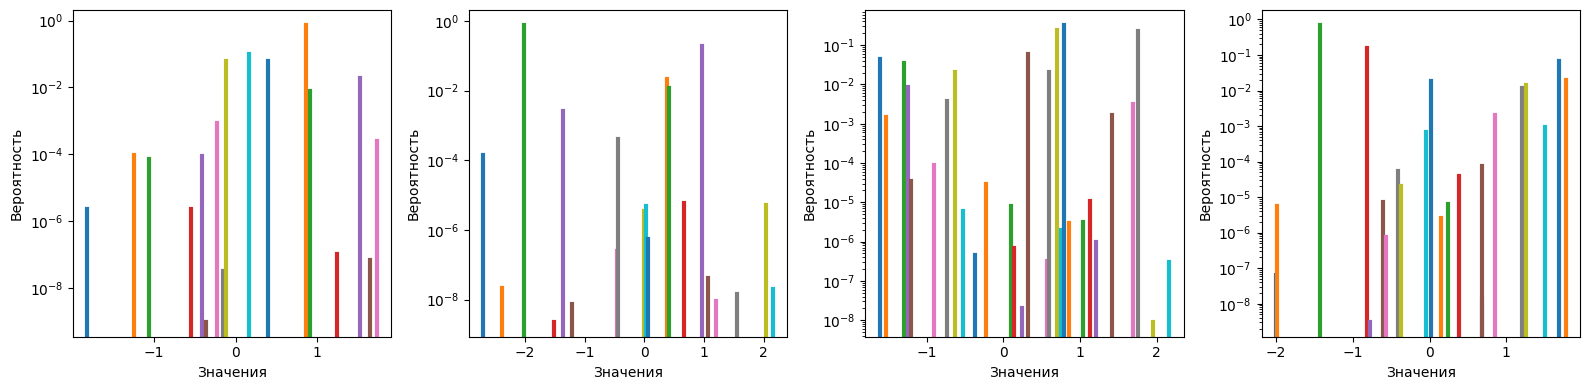

In [34]:
plt.figure(figsize=(16, 4))

for i in range(4):
    values, probs = dirichlet_processes(base_distibution=sps.norm, alpha=1)
    plt.subplot(1, 4, i + 1)
    for k in range(len(values)):
        plt.plot([values[k]] * 2, [0, probs[k]], lw=3)
    plt.xlabel("Значения")
    plt.ylabel("Вероятность")
    plt.yscale("log")
plt.tight_layout()

Повторите процедуру для $\alpha=10$ и $\alpha=0.1$.

Сделайте выводы.

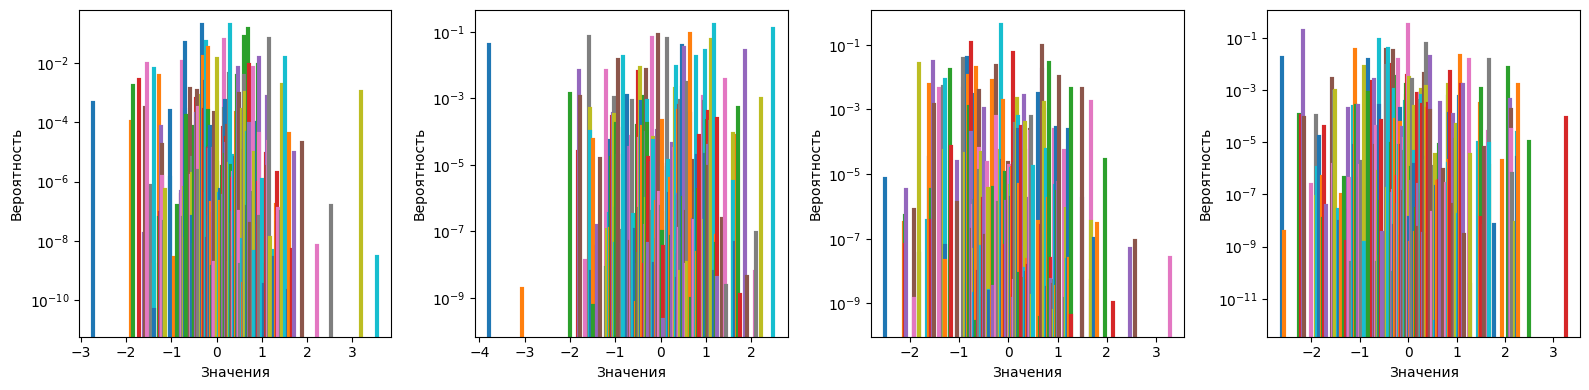

In [35]:
plt.figure(figsize=(16, 4))

for i in range(4):
    values, probs = dirichlet_processes(base_distibution=sps.norm, alpha=10)
    plt.subplot(1, 4, i + 1)
    for k in range(len(values)):
        plt.plot([values[k]] * 2, [0, probs[k]], lw=3)
    plt.xlabel("Значения")
    plt.ylabel("Вероятность")
    plt.yscale("log")
plt.tight_layout()

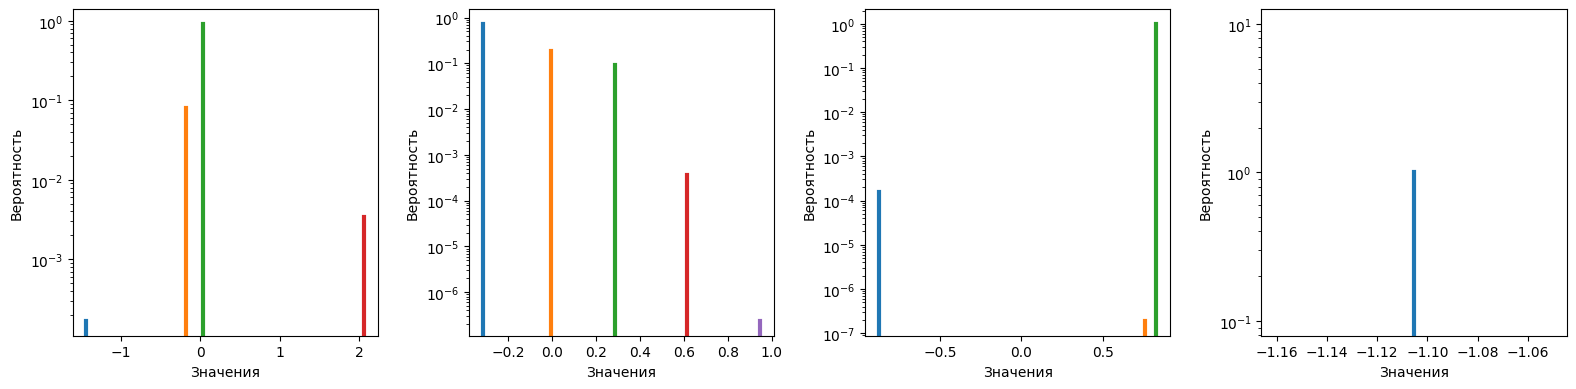

In [36]:
plt.figure(figsize=(16, 4))

for i in range(4):
    values, probs = dirichlet_processes(base_distibution=sps.norm, alpha=0.1)
    plt.subplot(1, 4, i + 1)
    for k in range(len(values)):
        plt.plot([values[k]] * 2, [0, probs[k]], lw=3)
    plt.xlabel("Значения")
    plt.ylabel("Вероятность")
    plt.yscale("log")
plt.tight_layout()

**Выводы**
Как видим, мы корректно реализовали процесс Дирихле. 

Ожидаемо, от параметра alpha напрямую зависит количество уникальных значений в нашем дискретном распределении. То есть чем больше alpha, тем больше уникальных значений.

__________________
### Задача 4.

Пусть выборка $X_1, ..., X_n$ имеет распределение смеси с неизвестным количеством компонент. Данные поступают последовательно, причем постепенно могут появляться новые кластеры, а старые &mdash; исчезать. Это означает, что мы не можем один раз по всей выборке определить оптимальное количество кластеров на основе какого-либо функционала. 

Такая задача может иметь смысл, например, для новостных агрегаторов, блог-платформ, социальных сетей. Мы можем получить векторное представление объектов (тексты статей, видеоролики), и далее для них решать задачу кластеризации. Но периодически могут появляться новые группы новостей, новые тренды, которые хотелось бы уметь автоматически выделять в отдельный кластер. В то же время, кластеры для устаревших новостей или трендов хотелось бы исключать. Возникает потребность в модели кластеризации, в которой можно автоматически добавлять новые кластеры, периодически обновляться на новых данных, а также "на лету" добавлять новые кластеры и удалять старые.

Определим модель следующим образом
* $\theta_1, \theta_2, ... \sim G_0$ &mdash; параметры каждого кластера, имеющие некоторое распределение $G_0$, являющееся базовым распределением в процессе stick-breaking;
* $V_1, V_2, ... \sim Beta(1, \alpha)$ &mdash; параметры доли отламываемой палки в процессе stick-breaking;
* $\pi_k = V_k \prod\limits_{j=1}^{k-1} (1-V_j)$ &mdash; параметры вероятностей кластеров;
* $Y_1, ..., Y_n$ &mdash; номера кластеров в виде one-hot векторов, то есть $Y_i = (Y_{ik})_{k=1}^\infty$, где $Y_{ik}\in\{0, 1\}$ и $\mathsf{P}(Y_{ik} = 1\ |\ \pi) = \pi_k$;
* $X_1, ..., X_n$ &mdash; выборка, в которой условное распределение $(X_i\:|\:Y_{ik}=1,\theta=t)$ описывается плотностью $p_{t_k}(x)$.

Совместное распределение всех величин в такой модели имеет вид
$$p(x, y, v, t) = \overbrace{\left[   \prod_{k=1}^{\infty} g_0(t_k) \rho_{\alpha}(v_k)   \right]}^{\text{\textcolor{green}{выбор параметров кластеров}}}   \prod_{i=1}^n   \prod_{k=1}^{\infty}   \left[    \overbrace{v_k \prod_{j=1}^{k-1}(1-v_j)}^{\text{\textcolor{green}{вер-ть кластера}}}  \cdot p_{t_k}(x_i)    \right]^{y_{ik}},$$
где $g_0$ &mdash; плотность распределения $G_0$, а $\rho_{\alpha}$ &mdash; плотность распределения $Beta(1, \alpha)$. Формула отличается от формулы совместного распределения простой смеси тем, что в данном случае параметры кластера случайны, и самих кластеров бесконечно.

Рассмотрим вариационное семейство, в котором наборы $(\theta_k)_{k=1}^\infty, (V_k)_{k=1}^\infty, (Y_i)_{i=1}^n$ независимы, причем распределение каждого из этих наборов произвольное.

$\square$
## Задание выполнено в PDF
$\blacksquare$

**1.** Выполните шаг для обновления распределения $(Y_i)_{i=1}^n$. На основе полученного распределения предложите условия, при которых
* можно исключить все кластеры с номерами больше $K$,
* можно исключить некоторые кластеры с номерами меньше $K$.

**2.** Выполните шаг для обновления распределения $(V_k)_{k=1}^\infty$. Проинтерпретируйте параметры полученного распределения. На основе полученного распределения предложите условие, при котором стоит добавить новые кластеры.

**3.** Выпишите шаг для обновления распределения $(\theta_k)_{k=1}^\infty$ 
* в общем случае формулой в виде пропорциональности;
* в случае если $p_{t_k}(x)$ &mdash; плотность распределения $\mathcal{N}(a_k, \Sigma^2_k)$ и $G_0$ &mdash; неинформативное, а в вариационном семестве для $(\theta_k)_{k=1}^\infty$ рассматривается вырожденное распределение (т.е. нужно найти моду, см. сведение VI к EM).

*Подсказка.* Достаточно свести второй случай к уже решенной ранее задаче и выписать ответ.

**4.** Распишите ELBO.

**5.** Вычислите все математические ожидания по вариационным распределениям $(V_k)_{k=1}^\infty, (Y_i)_{i=1}^n$.

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока